<img src="../resources/HTLstp-RGB150.png" alt="HTL" width=200>
REFR - Prof. Franz Reichel

DSAI - 4XHIF Klasse

---

# MNIST – Klassifikation der Ziffern 0–9 (Supervised Learning)

Dieses Notebook zeigt ein einfaches Klassifikationsbeispiel mit dem bekannten **MNIST Dataset**.
> MNIST = Modified National Institute of Standards and Technology

Wir trainieren ein Modell zur Erkennung handgeschriebener Zahlen 0–9.


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

%matplotlib inline


## 1. MNIST Dataset laden

In [33]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist['data'], mnist['target'].astype(int)

X.shape, y.shape

((70000, 784), (70000,))

## 2. Beispielbilder anzeigen

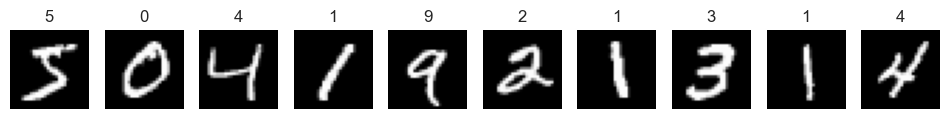

In [57]:
fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for i in range(10):
    axes[i].imshow(X[i].reshape(28, 28), cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(str(y[i]))
plt.show()


## 3. Train/Test-Split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

X_train.shape, X_test.shape


((63000, 784), (7000, 784))

## 4. Modell trainieren – Logistic Regression

In [51]:
#model = LogisticRegression(max_iter=5000)

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=10000)
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)


0.915

## 5. Klassifikationsbericht

In [54]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       683
           1       0.94      0.98      0.96       800
           2       0.90      0.88      0.89       674
           3       0.90      0.90      0.90       760
           4       0.91      0.92      0.92       611
           5       0.89      0.87      0.88       658
           6       0.92      0.95      0.94       677
           7       0.92      0.94      0.93       724
           8       0.90      0.84      0.87       693
           9       0.91      0.90      0.91       720

    accuracy                           0.92      7000
   macro avg       0.91      0.91      0.91      7000
weighted avg       0.91      0.92      0.91      7000



## 6. Beispielvorhersage

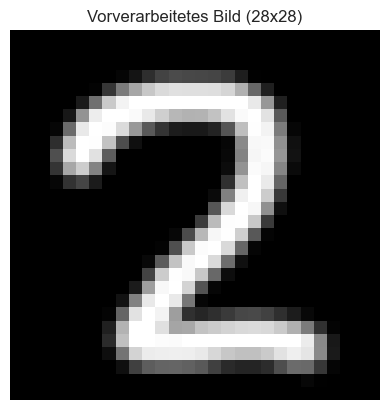

Vorhersage: 2
Wahrscheinlichkeiten: [1.81405361e-16 1.41781546e-20 9.95879023e-01 2.14744482e-03
 3.13016548e-13 1.34419142e-10 1.02822571e-26 6.68290925e-23
 1.97353216e-03 2.90039200e-18]


In [79]:
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Pfad zu deinem eigenen Bild
# -------------------------------------------------------
#custom_path = "./data/my_digit.png"   # <-- HIER DEIN BILD EINTRAGEN
custom_path = ("./data/franks_two.png")

# -------------------------------------------------------
# Bild laden
# -------------------------------------------------------
img = Image.open(custom_path)


# -------------------------------------------------------
# 1) in Graustufen umwandeln
# 2) auf 28×28 Pixel skalieren
# 3) invertieren (schwarzer Hintergrund wie MNIST)
# -------------------------------------------------------
img = img.convert("L")                 # Graustufen
img = img.resize((28, 28))             # Größe anpassen
#img = ImageOps.invert(img)             # MNIST: weiß = Zahl

# -------------------------------------------------------
# In numpy umwandeln
# -------------------------------------------------------
img_arr = np.array(img)

plt.imshow(img_arr, cmap="gray")
plt.title("Vorverarbeitetes Bild (28x28)")
plt.axis("off")
plt.show()

# -------------------------------------------------------
# Flatten wie bei MNIST
# -------------------------------------------------------
img_flat = img_arr.reshape(1, -1)  # (1, 784)

# -------------------------------------------------------
# Vorhersage
# -------------------------------------------------------
prediction = model.predict(img_flat)[0]
probs = model.predict_proba(img_flat)[0]

print("Vorhersage:", prediction)
print("Wahrscheinlichkeiten:", probs)

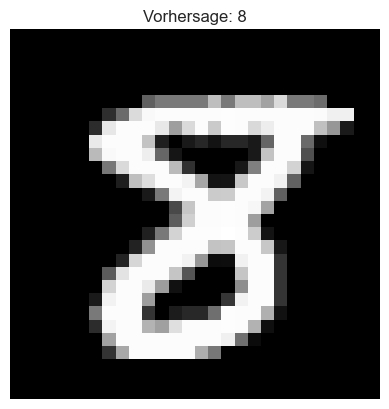

In [9]:
sample_index = 0
sample_img = X_test[sample_index]

plt.imshow(sample_img.reshape(28, 28), cmap="gray")
plt.axis("off")
plt.title(f"Vorhersage: {model.predict([sample_img])[0]}")
plt.show()
